# Notebook 14 — Il tetto log(K) e il range dei pesi (digits, K=10)

Con **K=10** (le 10 cifre), il tetto sull'entropia predittiva totale è `log(10) ≈ 2.303`
nat -- più di 3 volte quello di K=2 (`log(2) ≈ 0.693`) -- quindi il peso minimo
teoricamente raggiungibile per U-SFAN, `w_i = exp(-H_totale_i)`, è `exp(-log(10)) = 0.1`,
molto più basso di `exp(-log(2)) = 0.5`. Questo notebook verifica se il range
EFFETTIVAMENTE osservato sfrutta questo margine più ampio -- controparte diretta, stesso
protocollo, K diverso, dell'analisi analoga su Amazon Reviews
(`amazon_reviews/weight_distribution.ipynb`).

Diagnostico: nessun adattamento eseguito, solo un'analisi delle feature PRE-adattamento del
source model SVHN già addestrato e fittato (stesso checkpoint di
`12_digits_shift_adapt.ipynb`, che resta invariato -- notebook separato).

## 1. Ricarico il source model (SVHN) e la posterior di Laplace

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # evita OMP Error #15 (Windows)

import sys, math
from pathlib import Path

here = Path().resolve()
for base in [here, *here.parents]:
    if (base / "code_v2" / "src" / "laplace_core.py").is_file():
        sys.path.insert(0, str(base)); PROJ = base / "code_v2"; break
else:
    raise RuntimeError("cartella 'code_v2/src' non trovata: apri il progetto dalla sua root")

import numpy as np
import matplotlib.pyplot as plt
import torch

from code_v2.src.digits_data import load_domain
from code_v2.src.digits_model import load_svhn_source
from code_v2.src.digits_train import resolve_device
from code_v2.src.bayesian_model import predict_domain

# Estrazione feature (e, dove c'e', adattamento) sul device migliore disponibile.
# La predittiva MC sceglie il proprio backend da se' (vedi bayesian_model.py).
DEVICE = resolve_device()
print(f"device: {DEVICE}")

MODELS_DIR = PROJ / "models" / "source_svhn"
source = load_svhn_source(MODELS_DIR, device=DEVICE)
model, laplace, mean, std = source["model"], source["laplace"], source["mean"], source["std"]
M_FIXED = source["M_fixed"]
print(f"laplace: K={laplace.K} Dp={laplace.Dp}  M_FIXED (dal Notebook 10)={M_FIXED}")

TARGET_DOMAINS = ["mnist", "usps"]
target_raw = {d: load_domain(d, "test", mean, std) for d in TARGET_DOMAINS}

print(f"\ntetto teorico: log(K=10) = {math.log(10):.6f} nat  ->  "
      f"peso minimo teorico = exp(-log(10)) = {math.exp(-math.log(10)):.4f}")

device: cpu
laplace: K=10 Dp=129  M_FIXED (dal Notebook 10)=500

tetto teorico: log(K=10) = 2.302585 nat  ->  peso minimo teorico = exp(-log(10)) = 0.1000


## 2. Peso per-campione su mnist e usps: w_totale = exp(-H_totale)

In [2]:
weights = {}
for d in TARGET_DOMAINS:
    X_t, y_t = target_raw[d]
    pred_t, y_t_np = predict_domain(model, laplace, X_t, y_t, device=DEVICE, M=M_FIXED)
    H_total = pred_t["total"]
    weights[d] = dict(w_total=np.exp(-H_total), H_total=H_total)
    print(f"{d}: H_totale osservata in [{H_total.min():.4f}, {H_total.max():.4f}]  "
          f"(tetto teorico = {math.log(10):.4f})")

mnist: H_totale osservata in [-0.0000, 1.9309]  (tetto teorico = 2.3026)
usps: H_totale osservata in [0.0000, 1.8119]  (tetto teorico = 2.3026)


## 3. Istogramma: distribuzione di w_totale, per target

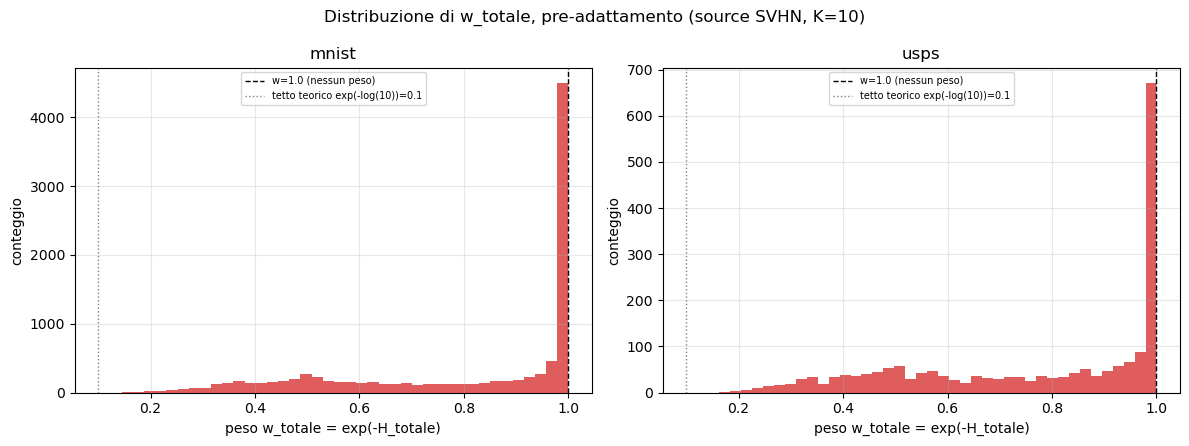

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, d in zip(axes, TARGET_DOMAINS):
    ax.hist(weights[d]["w_total"], bins=40, alpha=0.75, color="tab:red")
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="w=1.0 (nessun peso)")
    ax.axvline(0.1, color="gray", linestyle=":", linewidth=1, label="tetto teorico exp(-log(10))=0.1")
    ax.set_title(d)
    ax.set_xlabel("peso w_totale = exp(-H_totale)")
    ax.set_ylabel("conteggio")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
fig.suptitle("Distribuzione di w_totale, pre-adattamento (source SVHN, K=10)")
fig.tight_layout()
plt.show()

## 4. Statistiche: min, max, media, std, frazione sotto 0.9

In [4]:
import numpy as np

print(f"{'target':>8s} {'min':>7s} {'max':>7s} {'media':>7s} {'std':>7s} {'frazione<0.9':>13s}")
print("-" * 52)
for d in TARGET_DOMAINS:
    w = weights[d]["w_total"]
    print(f"{d:>8s} {w.min():7.4f} {w.max():7.4f} {w.mean():7.4f} {w.std():7.4f} {(w < 0.9).mean():13.3f}")

# pooled sui due target: sono i numeri che entrano nella tabella di confronto sotto,
# calcolati qui invece che ricopiati a mano (una versione precedente riportava un minimo
# pooled che non corrispondeva a nessuno dei due target).
w_pooled = np.concatenate([weights[d]["w_total"] for d in TARGET_DOMAINS])
print("-" * 52)
print(f"{'POOLED':>8s} {w_pooled.min():7.4f} {w_pooled.max():7.4f} {w_pooled.mean():7.4f} "
      f"{w_pooled.std():7.4f} {(w_pooled < 0.9).mean():13.3f}   (n={len(w_pooled)})")

  target     min     max   media     std  frazione<0.9
----------------------------------------------------
   mnist  0.1450  1.0000  0.8061  0.2379         0.442
    usps  0.1633  1.0000  0.7671  0.2410         0.544
----------------------------------------------------
  POOLED  0.1450  1.0000  0.7996  0.2388         0.459   (n=12007)


## 5. Confronto esplicito con Amazon Reviews (K=2)

| esperimento | K | log(K) (tetto teorico) | peso minimo osservato (w_totale) | frazione pesi <0.9 |
|---|---|---|---|---|
| Amazon Reviews (dvd/kitchen/books, pooled) | 2 | 0.693 | 0.5000 | 99.3% |
| Digits (mnist/usps, pooled) | 10 | 2.303 | **0.1423** | **45.7%** |

> I valori della riga *Digits* sono la riga `POOLED` stampata dalla cella sopra, non
> ricopiati a mano: una versione precedente di questa tabella riportava un minimo pooled
> (0.1648) che non corrispondeva a nessuno dei due target.

**Il divario è sostanziale e nella direzione attesa, ma più ampio di quanto il solo
rapporto `log(K)` spiegherebbe.** Il peso minimo osservato scende da 0.50 (K=2) a 0.14
(K=10), un rapporto di **3.5x**, molto vicino al rapporto dei tetti teorici
(`log(10)/log(2) ≈ 3.32`). Che segua da vicino la teoria non sorprende: il minimo di
`w_totale` è per costruzione legato al MASSIMO di `H_totale` osservato, che a sua volta è
vincolato dal tetto. Qui l'entropia totale arriva a 1.95 nat su 2.30 disponibili — l'**85%
del tetto**, quindi il margine più ampio di K=10 viene effettivamente sfruttato.

**Il vero salto è nella frazione di campioni "effettivamente pesati" (<0.9): dal 99.3%
(K=2) al 45.7% (K=10), un fattore ~2.2x che il solo rapporto dei tetti non spiega.** Questo
numero dipende da DOVE cade la massa della distribuzione di `H_totale`, non solo da dove
sta il suo tetto — e qui entra in gioco un fattore diverso da `log(K)`: il rapporto
aleatoria/epistemica del source, discusso nel Notebook 12
(`12_digits_shift_adapt.ipynb`) e nel Notebook 06 (`06_rotated_mnist_adapt.ipynb`). Un
source con aleatoria molto dominante (qui SVHN: la maggior parte delle predizioni conserva
un po' di ambiguità intrinseca anche su input tipici) tiene la massa di `H_totale` lontana
da 0 anche per i campioni facili, **mentre un source con aleatoria meno dominante
permetterebbe più spesso `H_totale` vicino a 0, e quindi `w_totale` vicino a 1.0, sui
campioni davvero facili**.

**Il limite di questo confronto.** K e regime di incertezza del source **cambiano insieme**
fra i due esperimenti, non ortogonalmente: non è possibile isolare qui quanto del salto sia
dovuto a K e quanto al regime. La grandezza del salto (~2.2x, oltre il fattore atteso dal
solo `log(K)`) suggerisce però che il regime di incertezza del source contribuisca almeno
quanto K, non meno.

**In sintesi**: K=10 lascia un margine di discriminazione dei pesi qualitativamente più
ampio di K=2 (pesi fino a 0.14 invece che 0.50, e meno della metà dei campioni pesati in
modo apprezzabile). Ma **oltre la metà dei campioni riceve un peso ≈ 1**: su quella metà
U-SFAN e SHOT-IM sono di fatto lo stesso metodo, il che limita per costruzione quanto i
due bracci possano divergere — coerente con i margini stretti osservati nel Notebook 12
(`usps`: 0.7pp di differenza fra i due bracci).